# Stage 2: Out-of-Sample PCA Early-Warning Validation — Common Factor Framework

## Interpretation
Stage 1 is exploratory and may reveal different PCs that spike by coin.  
Stage 2 is deliberately stricter: it imposes a **common latent-factor framework** so that cross-coin comparisons are meaningful.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## 1. Load Data

In [2]:
# raw / clean daily data with depeg labels
dai = pd.read_parquet("clean_data/dai_clean.parquet")
pax = pd.read_parquet("clean_data/pax_clean.parquet")
usdc = pd.read_parquet("clean_data/usdc_clean.parquet")
usdt = pd.read_parquet("clean_data/usdt_clean.parquet")
ust = pd.read_parquet("clean_data/ust_clean.parquet")

# feature-engineered datasets used for PCA
df_dai_final = pd.read_parquet("clean_data/dai_final.parquet")
df_pax_final = pd.read_parquet("clean_data/pax_final.parquet")
df_usdc_final = pd.read_parquet("clean_data/usdc_final.parquet")
df_usdt_final = pd.read_parquet("clean_data/usdt_final.parquet")
df_ust_final = pd.read_parquet("clean_data/ust_final.parquet")

for name, df in {
    "DAI": dai, "USDC": usdc, "USDT": usdt, "USDP": pax, "UST": ust
}.items():
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.normalize()
    print(f"{name:>4} | rows={len(df):4d} | depegs={int(df['depeg'].sum())}")

 DAI | rows=1941 | depegs=5
USDC | rows=1941 | depegs=3
USDT | rows=1941 | depegs=2
USDP | rows=1941 | depegs=23
 UST | rows=1941 | depegs=1435


## 2. Split Functions

The split is time-based.  
- For UST, the test set should contain the **run-up to the May 2022 collapse**.  
- For USDC and DAI, the test set should contain their major stress/depeg episodes.  
- USDT and USDP are mainly used for **false-alarm validation**.

In [3]:
def split_equal_depegs(df, date_col="timestamp", target_col="depeg", end_date="2024-12-31"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    df = df[df[date_col] <= end_date].copy()

    if df[target_col].sum() == 0:
        split_idx = int(len(df) * 0.7) - 1
    else:
        cumsum = df[target_col].cumsum()
        total = cumsum.iloc[-1]
        split_idx = (cumsum - total / 2).abs().idxmin()

    train = df.iloc[: split_idx + 1].copy()
    test = df.iloc[split_idx + 1 :].copy()

    return train, test


def split_by_date(df, split_date, date_col="timestamp", end_date="2024-12-31"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    df = df[df[date_col] <= end_date].copy()

    train = df[df[date_col] <= pd.to_datetime(split_date)].copy()
    test = df[df[date_col] > pd.to_datetime(split_date)].copy()
    return train, test


def print_split_summary(name, train, test):
    print(f"{name}")
    print(f"  train: {train['timestamp'].min().date()} → {train['timestamp'].max().date()} | "
          f"rows={len(train)} | depegs={int(train['depeg'].sum())}")
    print(f"  test : {test['timestamp'].min().date()} → {test['timestamp'].max().date()} | "
          f"rows={len(test)} | depegs={int(test['depeg'].sum())}")
    print("-" * 80)

In [4]:
# coin-specific split dates.
# adjust these if needed after reviewing depeg timing more carefully.
MANUAL_SPLITS = {
    "DAI":  "2022-06-30",
    "USDC": "2022-06-30",
    "USDT": "2022-06-30",
}

splits_clean = {}

for name, df in {"DAI": dai, "USDC": usdc, "USDT": usdt, "USDP": pax}.items():
    if name in MANUAL_SPLITS:
        train, test = split_by_date(df, MANUAL_SPLITS[name])
    else:
        train, test = split_equal_depegs(df)
    splits_clean[name] = (train, test)
    print_split_summary(name, train, test)

# UST: keep only pre-collapse / collapse run-up period
ust_cut = ust[ust["timestamp"] <= "2022-05-11"].copy()
ust_train, ust_test = split_by_date(ust_cut, "2021-04-30")
splits_clean["UST"] = (ust_train, ust_test)
print_split_summary("UST", ust_train, ust_test)

DAI
  train: 2020-11-25 → 2022-06-30 | rows=583 | depegs=4
  test : 2022-07-01 → 2024-12-31 | rows=915 | depegs=1
--------------------------------------------------------------------------------
USDC
  train: 2020-11-25 → 2022-06-30 | rows=583 | depegs=1
  test : 2022-07-01 → 2024-12-31 | rows=915 | depegs=2
--------------------------------------------------------------------------------
USDT
  train: 2020-11-25 → 2022-06-30 | rows=583 | depegs=1
  test : 2022-07-01 → 2024-12-31 | rows=915 | depegs=1
--------------------------------------------------------------------------------
USDP
  train: 2020-11-25 → 2023-07-25 | rows=973 | depegs=11
  test : 2023-07-26 → 2024-12-31 | rows=525 | depegs=12
--------------------------------------------------------------------------------
UST
  train: 2020-11-25 → 2021-04-30 | rows=157 | depegs=16
  test : 2021-05-01 → 2022-05-11 | rows=376 | depegs=11
--------------------------------------------------------------------------------


## 3. Prepare PCA Datasets

We remove the target and raw OHLC columns, keeping only numeric explanatory features.

In [ ]:
def prepare_stablecoin_pca_df(df):
    drop_cols = [
        "depeg", "timeOpen", "timeClose", "timeHigh", "timeLow",
        "open", "high", "low", "close", "volume", "marketCap", "circulatingSupply",
        "depeg_future_1d", "depeg_future_3d", "depeg_future_5d",
        "depeg_future_7d", "depeg_future_14d", "depeg_future_30d"
    ]

    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"]).dt.normalize()
    out = out.drop(columns=[c for c in drop_cols if c in out.columns], errors="ignore")

    keep_cols = ["timestamp", "symbol"] + [
        c for c in out.columns
        if c not in ["timestamp", "symbol"] and pd.api.types.is_numeric_dtype(out[c])
    ]
    out = out[keep_cols].sort_values("timestamp").reset_index(drop=True)
    return out

In [6]:
# split the feature-engineered PCA data using the same dates as the clean label data
def split_final_df_by_clean_dates(final_df, train_clean, test_clean):
    final_df = final_df.copy()
    final_df["timestamp"] = pd.to_datetime(final_df["timestamp"]).dt.normalize()

    train_dates = set(pd.to_datetime(train_clean["timestamp"]).dt.normalize())
    test_dates = set(pd.to_datetime(test_clean["timestamp"]).dt.normalize())

    train = final_df[final_df["timestamp"].isin(train_dates)].copy()
    test = final_df[final_df["timestamp"].isin(test_dates)].copy()
    return train.sort_values("timestamp").reset_index(drop=True), test.sort_values("timestamp").reset_index(drop=True)

final_map = {
    "DAI": df_dai_final,
    "USDC": df_usdc_final,
    "USDT": df_usdt_final,
    "USDP": df_pax_final,
    "UST": df_ust_final,
}

splits_pca = {}
for coin in ["UST", "USDC", "DAI", "USDT", "USDP"]:
    tr_clean, te_clean = splits_clean[coin]
    tr, te = split_final_df_by_clean_dates(final_map[coin], tr_clean, te_clean)
    tr = prepare_stablecoin_pca_df(tr)
    te = prepare_stablecoin_pca_df(te)
    splits_pca[coin] = (tr, te)
    print(f"{coin}: PCA train rows={len(tr)}, PCA test rows={len(te)}")

UST: PCA train rows=127, PCA test rows=376
USDC: PCA train rows=553, PCA test rows=915
DAI: PCA train rows=553, PCA test rows=915
USDT: PCA train rows=553, PCA test rows=915
USDP: PCA train rows=943, PCA test rows=525


## 4. Fixed PCA on Training Only

This is the formal Stage 2 setup.
- Imputation is fit on training only.
- Standardisation is fit on training only.
- PCA is fit on training only.
- Test scores are projected using the training PCA.

In [8]:
def fit_fixed_pca(train_df, test_df, n_components=10):
    numeric_cols = [c for c in train_df.columns if c not in ["timestamp", "symbol"]]

    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(train_df[numeric_cols])
    X_test_imp = imputer.transform(test_df[numeric_cols])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled = scaler.transform(X_test_imp)

    n_components = min(n_components, X_train_scaled.shape[1])
    pca = PCA(n_components=n_components)
    X_train_pcs = pca.fit_transform(X_train_scaled)
    X_test_pcs = pca.transform(X_test_scaled)

    pc_cols = [f"PC{i+1}" for i in range(n_components)]

    return {
        "numeric_cols": numeric_cols,
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca,
        "loadings": pd.DataFrame(pca.components_.T, index=numeric_cols, columns=pc_cols),
        "explained_variance": pd.Series(pca.explained_variance_ratio_, index=pc_cols),
        "pc_scores_train": pd.DataFrame(X_train_pcs, columns=pc_cols, index=train_df.index),
        "pc_scores_test": pd.DataFrame(X_test_pcs, columns=pc_cols, index=test_df.index),
    }

In [10]:
pca_results = {}
for coin in ["UST", "USDC", "DAI", "USDT", "USDP"]:
    train_df, test_df = splits_pca[coin]
    pca_results[coin] = fit_fixed_pca(train_df, test_df, n_components=10)

pd.DataFrame({
    coin: pca_results[coin]["explained_variance"].head(10)
    for coin in pca_results
}).T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
UST,0.257505,0.169941,0.141368,0.080626,0.070944,0.063964,0.053050,0.035695,0.028046,0.023275
USDC,0.193763,0.164045,0.096337,0.086987,0.078654,0.067047,0.049587,0.046787,0.037487,0.033865
DAI,0.227608,0.145646,0.129279,0.103796,0.071173,0.052561,0.047348,0.038641,0.033145,0.030435
USDT,0.316293,0.148139,0.125983,0.081170,0.063532,0.041089,0.035797,0.031802,0.028938,0.023942
USDP,0.247840,0.158949,0.115037,0.083452,0.078767,0.049855,0.045704,0.038610,0.032234,0.031006


## 5. Common Factor Framework

This is the main conceptual change.

Instead of choosing different PCs for each coin, we pick a **common set of PCs** informed by Stage 1 exploratory results.

Examples:
- `COMMON_PCS = [0]` means **PC1 only**
- `COMMON_PCS = [0, 2]` means **PC1 and PC3**

Start with PC1, then optionally compare with PC1+PC3 in a robustness check.

In [11]:
# IMPORTANT: common PC choice across all coins
COMMON_PCS = [0, 2, 8]   # change to [0, 2] if Stage 1 supports PC1 + PC3

THRESHOLD = 3.0
WARNING_WINDOW_DAYS = 7
CONSECUTIVE_DAYS = 1
USE_NORMAL_ONLY_BENCHMARK = False

## 6. Training Benchmark and Test Z-Scores

We compute the benchmark distribution from the **training PC score series**.  
By default, the benchmark uses **all training days**. Set `USE_NORMAL_ONLY_BENCHMARK=True` if you want a normal-only benchmark.

In [12]:
def compute_training_benchmark(pca_result, train_clean_df, selected_pcs, use_normal_only=False):
    train_scores = pca_result["pc_scores_train"].copy()
    pc_cols = [f"PC{i+1}" for i in selected_pcs]

    if use_normal_only:
        mask = train_clean_df["depeg"].reset_index(drop=True).eq(0).values
        ref = train_scores.loc[mask, pc_cols]
    else:
        ref = train_scores[pc_cols]

    mu = ref.mean()
    sigma = ref.std(ddof=1).replace(0, np.nan)

    return {"pc_cols": pc_cols, "mu": mu, "sigma": sigma}


def compute_test_zscores(pca_result, benchmark):
    test_scores = pca_result["pc_scores_test"][benchmark["pc_cols"]]
    z = (test_scores - benchmark["mu"]) / benchmark["sigma"]
    z.columns = [f"z_{c}" for c in benchmark["pc_cols"]]
    return z

In [13]:
def generate_signal(z_scores, threshold=3.0, consecutive_days=1):
    any_exceed = (z_scores.abs() > threshold).any(axis=1).astype(int)

    if consecutive_days <= 1:
        return any_exceed

    rolling_sum = any_exceed.rolling(window=consecutive_days, min_periods=consecutive_days).sum()
    return (rolling_sum >= consecutive_days).astype(int)

## 7. Warning Labels and Metrics

A signal is treated as successful if it appears within the pre-depeg warning window.

In [14]:
def build_warning_labels(test_clean_df, signal, window_days=7, date_col="timestamp", depeg_col="depeg"):
    df = test_clean_df[[date_col, depeg_col]].copy().reset_index(drop=True)
    df["date"] = pd.to_datetime(df[date_col]).dt.normalize()
    df["signal"] = signal.reset_index(drop=True).values
    df["depeg"] = df[depeg_col].values

    depeg_dates = df.loc[df["depeg"] == 1, "date"].values

    def min_lead(d):
        future = depeg_dates[depeg_dates >= d]
        if len(future) == 0:
            return np.nan
        return (future[0] - d) / np.timedelta64(1, "D")

    df["lead_days"] = df["date"].apply(min_lead)
    df["label"] = ((df["lead_days"] >= 0) & (df["lead_days"] <= window_days)).astype(int)
    return df[["date", "signal", "depeg", "label", "lead_days"]]


def compute_metrics(labeled_df, coin=""):
    y_true = labeled_df["label"].values
    y_pred = labeled_df["signal"].values

    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())

    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if not (np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0)
        else np.nan
    )
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    tp_mask = (y_pred == 1) & (y_true == 1)
    avg_lead = labeled_df.loc[tp_mask, "lead_days"].dropna().mean()
    false_alarms_per_month = FP / (len(labeled_df) / 30.44) if len(labeled_df) > 0 else np.nan

    return {
        "coin": coin,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "avg_lead_days": avg_lead,
        "false_alarms_per_month": false_alarms_per_month,
        "n_test_days": len(labeled_df),
    }

In [15]:
def run_oos_evaluation(coin, common_pcs=None, threshold=3.0,
                       warning_window_days=7, consecutive_days=1,
                       use_normal_only_benchmark=False):
    if common_pcs is None:
        common_pcs = COMMON_PCS

    pca_result = pca_results[coin]
    train_clean_df, test_clean_df = splits_clean[coin]

    benchmark = compute_training_benchmark(
        pca_result=pca_result,
        train_clean_df=train_clean_df,
        selected_pcs=common_pcs,
        use_normal_only=use_normal_only_benchmark,
    )

    z_scores = compute_test_zscores(pca_result, benchmark)
    signal = generate_signal(z_scores, threshold=threshold, consecutive_days=consecutive_days)
    labeled_df = build_warning_labels(test_clean_df, signal, window_days=warning_window_days)
    metrics = compute_metrics(labeled_df, coin=coin)

    return {
        "coin": coin,
        "benchmark": benchmark,
        "z_scores": z_scores,
        "signal": signal,
        "labeled_df": labeled_df,
        "metrics": metrics,
    }

## 8. Run Stage 2 on All Coins

In [16]:
results = {}
for coin in ["UST", "USDC", "DAI", "USDT", "USDP"]:
    results[coin] = run_oos_evaluation(
        coin=coin,
        common_pcs=COMMON_PCS,
        threshold=THRESHOLD,
        warning_window_days=WARNING_WINDOW_DAYS,
        consecutive_days=CONSECUTIVE_DAYS,
        use_normal_only_benchmark=USE_NORMAL_ONLY_BENCHMARK,
    )

metrics_df = pd.DataFrame([v["metrics"] for v in results.values()]).set_index("coin")
metrics_df

,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,false_alarms_per_month,n_test_days
coin,,,,,,,,,,,
UST,13,74,263,26,0.149425,0.333333,0.206349,0.780415,1.615385,5.990851,376
USDC,8,831,75,1,0.009535,0.888889,0.018868,0.082781,3.375000,27.645508,915
DAI,8,867,40,0,0.009143,1.000000,0.018120,0.044101,3.500000,28.843148,915
USDT,1,158,749,7,0.006289,0.125000,0.011976,0.825799,0.000000,5.256306,915
USDP,20,22,434,49,0.476190,0.289855,0.360360,0.951754,2.050000,1.275581,525


## 9. Cross-Coin Evaluation

We group the results into:
- **Main collapse prediction**: UST
- **External validation**: USDC, DAI
- **False-alarm validation**: USDT, USDP

In [17]:
ROLE_MAP = {
    "UST": "Main collapse prediction",
    "USDC": "External validation",
    "DAI": "External validation",
    "USDT": "False-alarm validation",
    "USDP": "False-alarm validation",
}

cross_coin = metrics_df.reset_index().copy()
cross_coin["role"] = cross_coin["coin"].map(ROLE_MAP)
cross_coin = cross_coin[
    ["role", "coin", "precision", "recall", "f1", "specificity",
     "avg_lead_days", "false_alarms_per_month", "TP", "FP", "TN", "FN", "n_test_days"]
].sort_values(["role", "coin"])

cross_coin

,role,coin,precision,recall,f1,specificity,avg_lead_days,false_alarms_per_month,TP,FP,TN,FN,n_test_days
2,External validation,DAI,0.009143,1.000000,0.018120,0.044101,3.500000,28.843148,8,867,40,0,915
1,External validation,USDC,0.009535,0.888889,0.018868,0.082781,3.375000,27.645508,8,831,75,1,915
4,False-alarm validation,USDP,0.476190,0.289855,0.360360,0.951754,2.050000,1.275581,20,22,434,49,525
3,False-alarm validation,USDT,0.006289,0.125000,0.011976,0.825799,0.000000,5.256306,1,158,749,7,915
0,Main collapse prediction,UST,0.149425,0.333333,0.206349,0.780415,1.615385,5.990851,13,74,263,26,376


In [18]:
cross_coin.groupby("role")[["precision", "recall", "f1", "specificity", "avg_lead_days", "false_alarms_per_month"]].mean(numeric_only=True)

,precision,recall,f1,specificity,avg_lead_days,false_alarms_per_month
role,,,,,,
External validation,0.009339,0.944444,0.018494,0.063441,3.437500,28.244328
False-alarm validation,0.241240,0.207428,0.186168,0.888777,1.025000,3.265943
Main collapse prediction,0.149425,0.333333,0.206349,0.780415,1.615385,5.990851


## 10. Visual Diagnostics

These plots show whether the selected common PCs produce clear warning signals before depeg events.

In [19]:
def plot_signal_timeline(result, threshold=3.0, figsize=(14, 4)):
    coin = result["coin"]
    labeled_df = result["labeled_df"]
    z_scores = result["z_scores"]

    dates = labeled_df["date"].values
    fig, axes = plt.subplots(len(z_scores.columns), 1, figsize=figsize, sharex=True)

    if len(z_scores.columns) == 1:
        axes = [axes]

    for ax, col in zip(axes, z_scores.columns):
        ax.plot(dates, z_scores[col].values, lw=1.2, label=col)
        ax.axhline(threshold, ls="--", lw=1)
        ax.axhline(-threshold, ls="--", lw=1)

        in_window = labeled_df["label"].values == 1
        starts = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == 1)[0]
        ends = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == -1)[0]

        for s, e in zip(starts, ends):
            ax.axvspan(dates[s], dates[min(e, len(dates)-1)], alpha=0.15)

        for dd in labeled_df.loc[labeled_df["depeg"] == 1, "date"].values:
            ax.axvline(dd, lw=1.4)

        ax.set_ylabel(col)
        ax.grid(alpha=0.25)
        ax.legend(loc="upper left", fontsize=8)

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{coin} — out-of-sample common-factor z-score timeline", fontweight="bold")
    plt.tight_layout()
    plt.show()

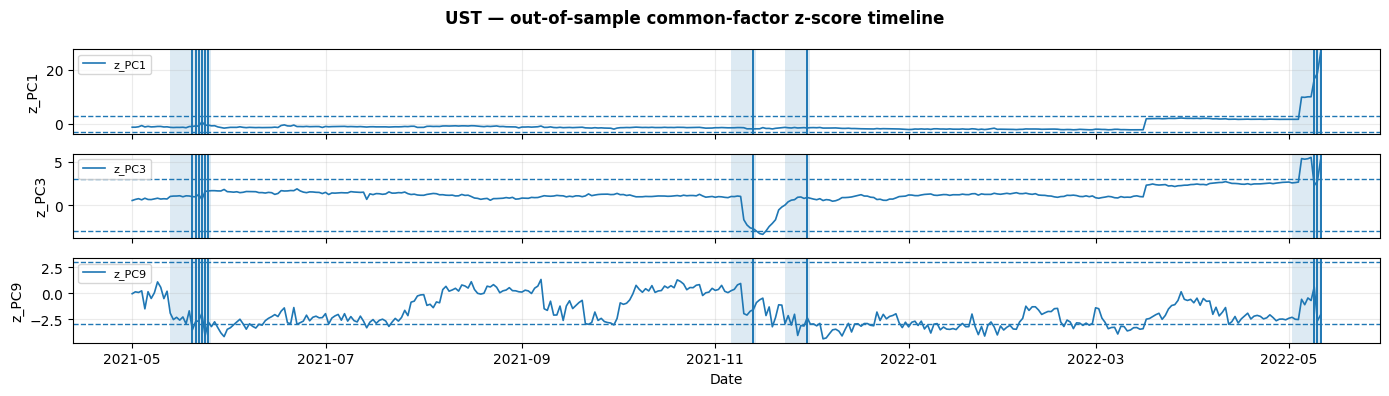

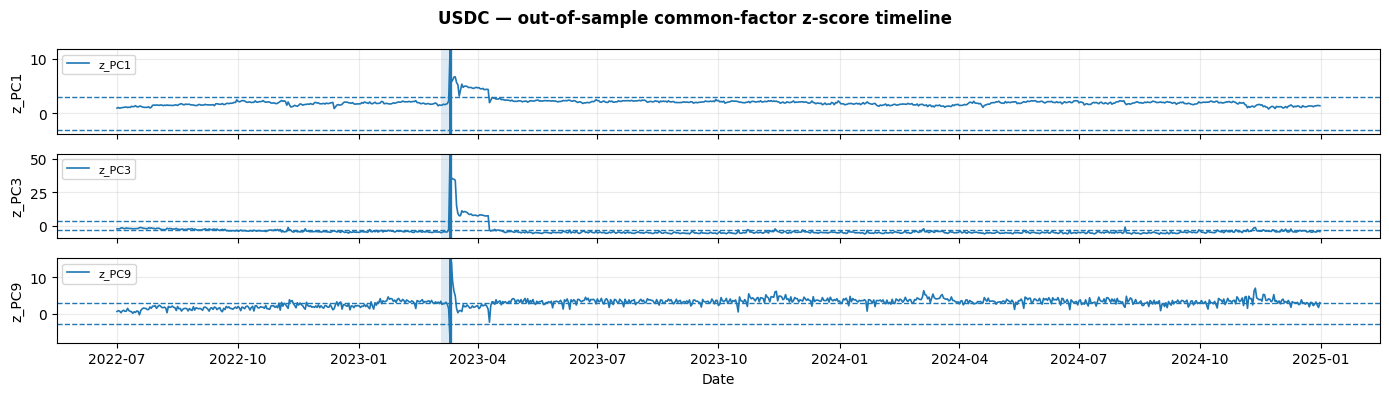

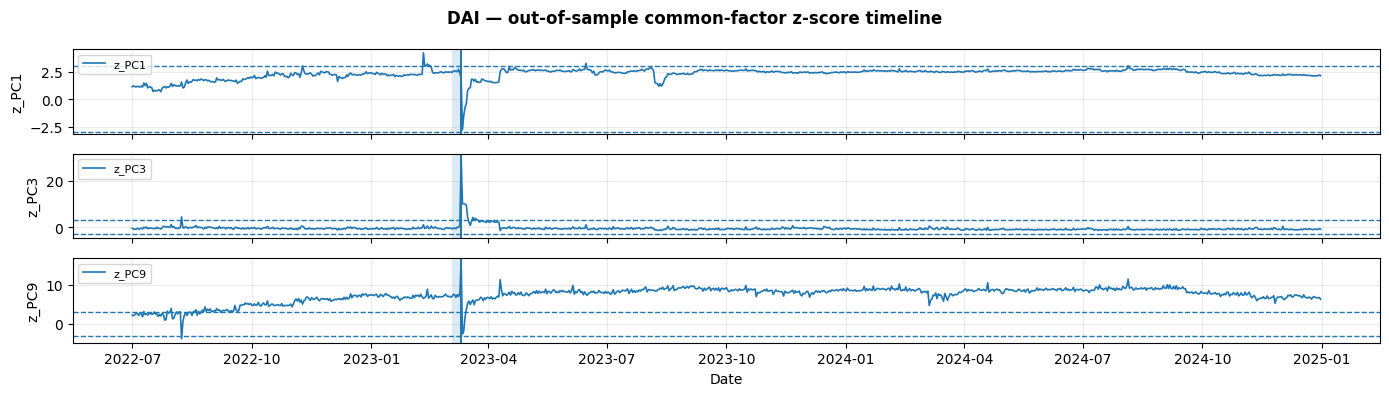

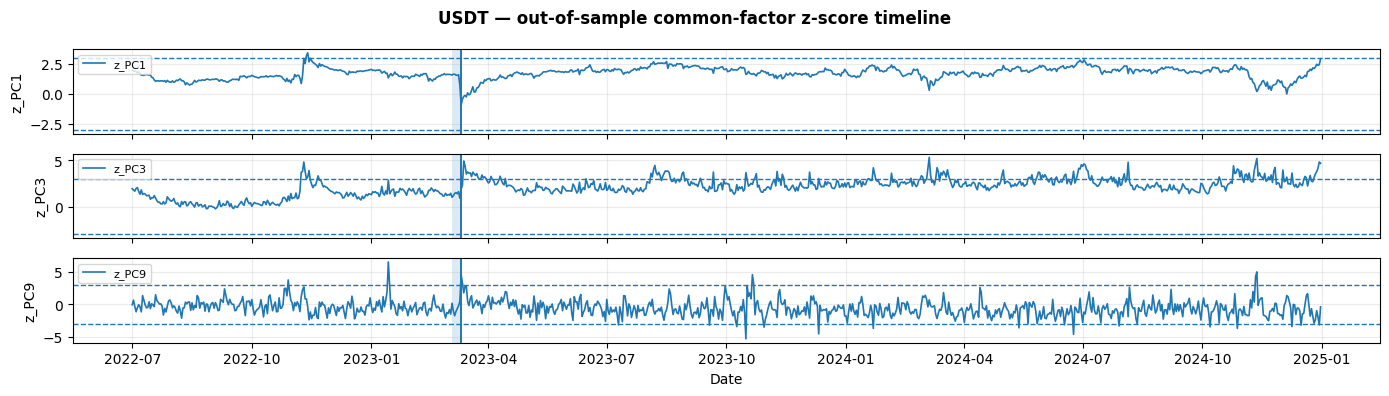

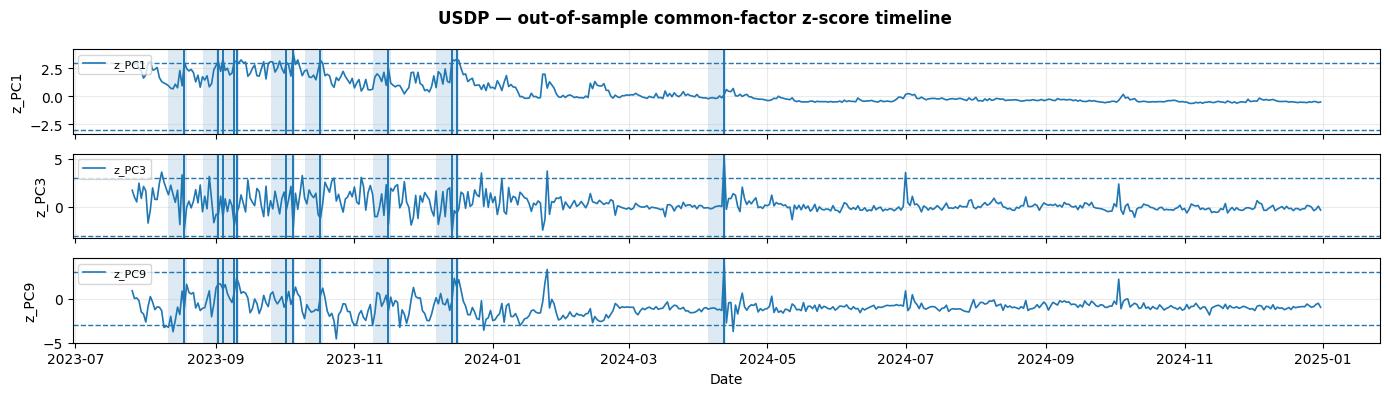

In [20]:
for coin in ["UST", "USDC", "DAI", "USDT", "USDP"]:
    plot_signal_timeline(results[coin], threshold=THRESHOLD)

## 11. Sensitivity Analysis

We can compare:
- different common PC sets, such as `[0]` vs `[0, 2]`
- different thresholds, such as 2.0, 2.5, 3.0
- different warning windows, such as 5 vs 7 days

In [21]:
def sensitivity_sweep(coin, common_pc_sets=None, thresholds=(2.0, 2.5, 3.0), windows=(5, 7), consecutive_days=1):
    if common_pc_sets is None:
        common_pc_sets = [[0], [0, 2]]

    rows = []
    for pcs in common_pc_sets:
        for thr in thresholds:
            for win in windows:
                result = run_oos_evaluation(
                    coin=coin,
                    common_pcs=pcs,
                    threshold=thr,
                    warning_window_days=win,
                    consecutive_days=consecutive_days,
                    use_normal_only_benchmark=USE_NORMAL_ONLY_BENCHMARK,
                )
                row = result["metrics"].copy()
                row["common_pcs"] = str([f"PC{i+1}" for i in pcs])
                row["threshold"] = thr
                row["window_days"] = win
                rows.append(row)

    out = pd.DataFrame(rows)
    return out.sort_values(["f1", "precision", "recall"], ascending=False)

ust_sweep = sensitivity_sweep("UST")
ust_sweep.head(12)

,coin,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,false_alarms_per_month,n_test_days,common_pcs,threshold,window_days
2,UST,7,0,345,24,1.000000,0.225806,0.368421,1.000000,1.428571,0.000000,376,['PC1'],2.5,5
4,UST,7,0,345,24,1.000000,0.225806,0.368421,1.000000,1.428571,0.000000,376,['PC1'],3.0,5
10,UST,7,2,343,24,0.777778,0.225806,0.350000,0.994203,1.428571,0.161915,376,"['PC1', 'PC3']",3.0,5
9,UST,12,21,316,27,0.363636,0.307692,0.333333,0.937685,2.416667,1.700106,376,"['PC1', 'PC3']",2.5,7
8,UST,10,23,322,21,0.303030,0.322581,0.312500,0.933333,1.600000,1.862021,376,"['PC1', 'PC3']",2.5,5
3,UST,7,0,337,32,1.000000,0.179487,0.304348,1.000000,1.428571,0.000000,376,['PC1'],2.5,7
5,UST,7,0,337,32,1.000000,0.179487,0.304348,1.000000,1.428571,0.000000,376,['PC1'],3.0,7
11,UST,7,2,335,32,0.777778,0.179487,0.291667,0.994065,1.428571,0.161915,376,"['PC1', 'PC3']",3.0,7
7,UST,13,101,236,26,0.114035,0.333333,0.169935,0.700297,2.384615,8.176702,376,"['PC1', 'PC3']",2.0,7
6,UST,11,103,242,20,0.096491,0.354839,0.151724,0.701449,1.636364,8.338617,376,"['PC1', 'PC3']",2.0,5


## 12. Quick Loading Inspection

This is useful for economic interpretation of the common factors.

In [22]:
def top_loadings_table(pca_result, pc="PC1", top_n=10):
    loadings = pca_result["loadings"][pc].sort_values(key=lambda s: s.abs(), ascending=False)
    return pd.DataFrame({
        "feature": loadings.index[:top_n],
        "loading": loadings.values[:top_n]
    })

for coin in ["UST", "USDC", "DAI"]:
    print(f"\n{coin} — top loadings for PC1")
    display(top_loadings_table(pca_results[coin], pc="PC1", top_n=10))


UST — top loadings for PC1


,feature,loading
0,fed_funds_rate,0.337727
1,Unnamed: 0,-0.326768
2,downward_price_deviation_30d,0.291938
3,price_deviation_5d,0.288801
4,realized_daily_volatility,0.287043
5,price_deviation_30d,0.285185
6,downward_price_deviation_5d,0.283391
7,circulating_supply_percent_change_30d,-0.274042
8,market_cap_percent_change_30d,-0.271570
9,abs_peg_error,0.230700



USDC — top loadings for PC1


,feature,loading
0,circulating_supply_percent_change_30d,0.415141
1,market_cap_percent_change_30d,0.415000
2,market_cap_percent_change_7d,0.414668
3,circulating_supply_percent_change_7d,0.413748
4,market_cap_percent_change_24h,0.289985
5,circulating_supply_percent_change_24h,0.286533
6,fear_greed_index,-0.162506
7,fed_funds_rate,0.162120
8,peg_error,-0.145413
9,abs_peg_error,-0.110552



DAI — top loadings for PC1


,feature,loading
0,market_cap_percent_change_30d,0.369596
1,circulating_supply_percent_change_30d,0.369463
2,market_cap_percent_change_7d,0.361723
3,circulating_supply_percent_change_7d,0.359966
4,price_deviation_30d,-0.300919
5,fear_greed_index,-0.256295
6,fed_funds_rate,0.251037
7,market_cap_percent_change_24h,0.250414
8,circulating_supply_percent_change_24h,0.247783
9,price_deviation_5d,-0.230481
